In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay


In [20]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("¡Todas las librerías se cargaron correctamente!")

¡Todas las librerías se cargaron correctamente!


In [21]:
df = pd.read_csv('mexico_covid19.csv')
#df.tail()

# --- Useful Pandas commands to inspect the dataset (Comandos para inspeccionar) ---
#df.head()          # Display first 5 rows / Ver primeras 5 filas
#df.info()          # Display column types, non-null counts & memory usage / Ver tipos de datos y nulos
#df.describe()      # Summary statistics (mean, min, max, std) / Estadísticas descriptivas
#df.columns         # List all 41 column names / Listar nombres de las columnas
#df.shape           # Display dimensions (rows, columns) / Ver número de filas y columnas
#df.isnull().sum()  # Count missing (NaN) values per column / Contar valores nulos por columna
#df['TIPO_PACIENTE'].value_counts() # Check target distribution / Ver distribución de hospitalizados vs ambulatorios
#df.sample(10)
#df.shape
#df.info()
#df.head(10)
#df.describe()
#df.describe(include='all')
#df.isnull().sum() 
#df['OTRO_CASO'].value_counts()
#df.nunique()
#df.columns

# --- FASE 1: AUDITORÍA DE FUGA DE DATOS Y CLASIFICACIÓN DE COLUMNAS ---

En este primer paso metodológico, dividimos formalmente las **41 columnas del dataset** en tres categorías clave para garantizar que nuestro modelo aprenda únicamente con información real y honesta, evitando el grave error metodológico de la **Fuga de Datos (Data Leakage)**.

### 1. 🎯 Variable Objetivo (Target)
* **`TIPO_PACIENTE`**: Es lo que queremos predecir en el *Minuto 1* del Triage clínico.
  * `1` = Paciente Ambulatorio (Leve)
  * `2` = Paciente Hospitalizado (Grave)

### 2. 🚫 Variables Excluidas por Fuga de Datos (Leakage) e Irrelevancia
* **Fuga de Datos (Eventos futuros o confirmatorios tardíos):** `UCI`, `INTUBED`, `PNEUMONIA`, `FECHA_DEF`, `RESULTADO`.
  * **¿Por qué se excluyen rotundamente?** Un modelo de triage se utiliza en el *Minuto 1*, justo cuando el paciente llega a urgencias. En ese momento **no sabemos** si el paciente acabará en la UCI días después, si necesitará intubación, si morirá o cuál será el resultado final del test PCR de laboratorio (que suele tardar días). Si incluyéramos estas variables, el modelo haría "trampa" (*fuga de información del futuro*) y daría una precisión engañosa en pruebas, pero **sería completamente inútil en un hospital real**.
* **Variables Administrativas / Identificadores:** `id`, `FECHA_ARCHIVO`, `ID_REGISTRO`, `ENTIDAD_UM`, `ENTIDAD_RES`, `ENTIDAD_REGISTRO`, `ENTIDAD`, `ABR_ENT`, `MUNICIPIO_RES`, `LOCALIDAD_RES`, `FECHA_ACTUALIZACION`, `ORIGEN`, `SECTOR`, `ENTIDAD_NAC`, `DELAY`, `FECHA_INGRESO`, `FECHA_SINTOMAS`.
  * **¿Por qué se excluyen?** Son códigos administrativos o fechas de reporte que no reflejan el estado biológico ni la gravedad clínica del paciente al llegar al hospital.

### 3. ✅ Variables Predictoras Válidas (Features del Minuto 1)
* Son todas aquellas variables clínicas, síntomas y datos demográficos disponibles de forma inmediata al evaluar al paciente en urgencias: **`EDAD`, `SEXO`, `EMBARAZO`, `DIABETES`, `EPOC`, `ASMA`, `INMSUPR`, `HIPERTENSION`, `CARDIOVASCULAR`, `OBESIDAD`, `RENAL_CRONICA`, `TABAQUISMO`, `OTRA_COM`, `OTRO_CASO`, `MIGRANTE`, `PAIS_NACIONALIDAD`, `PAIS_ORIGEN`, `INDIGENA`, `HABLA_LENGUA_INDIG`**.

> 💡 **Nota para ti:** Si en algún momento quieres modificar esta clasificación (por ejemplo, para experimentar qué pasa si incluyes una columna administrativa), puedes editar manualmente las listas en la celda de código de abajo.

In [22]:
# --- CLASIFICACIÓN Y TRADUCCIÓN DE LAS 41 COLUMNAS ---
# Definimos las listas en Python. ¡Recuerda que puedes modificarlas manualmente cuando quieras!

target = 'TIPO_PACIENTE'

# 1. Variables Excluidas por Fuga de Datos (Data Leakage - Eventos futuros o confirmación tardía)
variables_fuga = [
    'UCI',          # Ingreso a Cuidados Intensivos (complicación hospitalaria posterior)
    'INTUBADO',      # Paciente intubado (procedimiento posterior al triage)
    'FECHA_DEF',    # Fecha de defunción (evento futuro incompatible con predicción temprana)
    'RESULTADO'     # Resultado confirmatorio de laboratorio (no disponible al minuto 1 en urgencias)
]

# 2. Variables Administrativas, Fechas de reporte y Códigos de ubicación (sin señal clínica del paciente)
variables_administrativas = [
    'id', 'FECHA_ARCHIVO', 'ID_REGISTRO', 'ENTIDAD_UM', 'ENTIDAD_RES', 
    'ENTIDAD_REGISTRO', 'ENTIDAD', 'ABR_ENT', 'MUNICIPIO_RES', 
    'FECHA_ACTUALIZACION', 'ORIGEN', 'SECTOR', 'ENTIDAD_NAC', 'DELAY', 
    'FECHA_INGRESO', 'FECHA_SINTOMAS', 'NACIONALIDAD', 'EMBARAZO', 'HABLA_LENGUA_INDIG','MIGRANTE','PAIS_NACIONALIDAD','PAIS_ORIGEN'
]

# 3. Variables Predictoras Válidas (Disponibles en el Minuto 1 de Triage clínico)
# Calculamos automáticamente las predictoras tomando todas las que no estén en las listas anteriores:
columnas_excluidas = [target] + variables_fuga + variables_administrativas
predictoras_validas = [col for col in df.columns if col not in columnas_excluidas]

# --- VERIFICACIÓN Y AUDITORÍA METODOLÓGICA ---
print("=== RESUMEN DE AUDITORÍA DE COLUMNAS ===")
print(f"🎯 Variable Objetivo (Target): 1 ({target})")
print(f"🚫 Variables excluidas por Fuga de Datos (Leakage): {len(variables_fuga)} -> {variables_fuga}")
print(f"📂 Variables Administrativas / Identificadores excluidos: {len(variables_administrativas)}")
print(f"✅ Variables Predictoras Válidas (Minuto 1): {len(predictoras_validas)}")

print("\n=== LISTADO FINAL DE PREDICTORAS VÁLIDAS ===")
for i, col in enumerate(predictoras_validas, 1):
    print(f"  {i:2d}. {col}")

# Verificamos la suma total de columnas:
total_clasificadas = 1 + len(variables_fuga) + len(variables_administrativas) + len(predictoras_validas)
print(f"\nTotal columnas en el dataset: {df.shape[1]} | Total columnas clasificadas: {total_clasificadas}")

if df.shape[1] == total_clasificadas:
    print("✨ ¡AUDITORÍA EXITOSA! El 100% de las columnas han sido clasificadas sin duplicados ni omisiones.")
else:
    print("⚠️ ATENCIÓN: Revisa las listas, hay columnas duplicadas u omitidas.")

=== RESUMEN DE AUDITORÍA DE COLUMNAS ===
🎯 Variable Objetivo (Target): 1 (TIPO_PACIENTE)
🚫 Variables excluidas por Fuga de Datos (Leakage): 4 -> ['UCI', 'INTUBADO', 'FECHA_DEF', 'RESULTADO']
📂 Variables Administrativas / Identificadores excluidos: 22
✅ Variables Predictoras Válidas (Minuto 1): 14

=== LISTADO FINAL DE PREDICTORAS VÁLIDAS ===
   1. SEXO
   2. NEUMONIA
   3. EDAD
   4. DIABETES
   5. EPOC
   6. ASMA
   7. INMUSUPR
   8. HIPERTENSION
   9. OTRA_COM
  10. CARDIOVASCULAR
  11. OBESIDAD
  12. RENAL_CRONICA
  13. TABAQUISMO
  14. OTRO_CASO

Total columnas en el dataset: 41 | Total columnas clasificadas: 41
✨ ¡AUDITORÍA EXITOSA! El 100% de las columnas han sido clasificadas sin duplicados ni omisiones.


In [23]:
# --- FASE 1: LIMPIEZA Y PREPROCESAMIENTO DE DATOS ---
# 1. Crear un sub-dataframe únicamente con el Target y las Predictoras Válidas (Cortafuegos de seguridad)
columnas_modelo = [target] + predictoras_validas
df_clean = df[columnas_modelo].copy()

print("=== 1. DIAGNÓSTICO DE CÓDIGOS ESPECIALES (97, 98, 99) ANTES DE LIMPIAR ===")
for col in df_clean.columns:
    if col != 'EDAD': # En la edad, 97, 98 y 99 son años reales, no faltantes
        conteos_especiales = df_clean[col].isin([97, 98, 99]).sum()
        if conteos_especiales > 0:
            porcentaje = (conteos_especiales / len(df_clean)) * 100
            print(f"  * {col:<15}: {conteos_especiales:8,d} registros faltantes ({porcentaje:.2f}%)")

# --- 2. BINARIZACIÓN DEL TARGET (TIPO_PACIENTE) ---
# Original: 1 = Ambulatorio, 2 = Hospitalizado
# Mapeo ML: 0 = Ambulatorio (clase referencia), 1 = Hospitalizado (clase de interés / riesgo)
df_clean[target] = df_clean[target].replace({1: 0, 2: 1})

# --- 3. RE-CODIFICACIÓN DE BOOLEANOS Y TRATAMIENTO DE NULOS ---
# Identificamos todas las columnas booleanas (todas excepto EDAD)
cols_booleanas = [col for col in predictoras_validas if col != 'EDAD']

for col in cols_booleanas:
    # Paso A: Convertir códigos de faltantes (97: No aplica, 98: Se ignora, 99: No especificado) a NaN de numpy
    df_clean[col] = df_clean[col].replace([97, 98, 99], np.nan)
    
    # Paso B: Convertir '2 = No' en '0' (y en SEXO: 2 = Hombre pasa a 0, 1 = Mujer se queda como 1)
    # Los valores 1 (Sí) se quedan exactamente como 1.
    df_clean[col] = df_clean[col].replace(2, 0)

# --- 4. VERIFICACIÓN DE EDAD ---
# Asegurarnos de que no haya edades negativas o absurdas (> 120 años)
edades_invalidas = df_clean[df_clean['EDAD'] < 0].shape[0] + df_clean[df_clean['EDAD'] > 120].shape[0]
if edades_invalidas > 0:
    print(f"\n⚠️ Se encontraron {edades_invalidas} registros con edades inválidas (<0 o >120). Se convertirán en NaN.")
    df_clean.loc[(df_clean['EDAD'] < 0) | (df_clean['EDAD'] > 120), 'EDAD'] = np.nan

# --- VERIFICACIÓN FINAL DEL DATASET LIMPIO ---
print("\n=== 2. AUDITORÍA DEL DATASET LIMPIO (df_clean) ===")
print(f"Dimensiones finales: {df_clean.shape[0]:,d} filas x {df_clean.shape[1]} columnas")
print("\nDistribución del Target Binarizado (TIPO_PACIENTE):")
conteo_target = df_clean[target].value_counts(dropna=False)
for val, count in conteo_target.items():
    etiqueta = "Hospitalizado (1)" if val == 1 else "Ambulatorio (0)"
    print(f"  * {etiqueta:<18}: {count:10,d} ({count/len(df_clean)*100:.2f}%)")

print("\nConteo total de valores nulos (NaN) resultantes por columna:")
nulos_por_col = df_clean.isnull().sum()
print(nulos_por_col[nulos_por_col > 0])
print("\n✨ ¡Limpieza completada con éxito! Todas las variables están estandarizadas (0 y 1) y listas para ML.")


=== 1. DIAGNÓSTICO DE CÓDIGOS ESPECIALES (97, 98, 99) ANTES DE LIMPIAR ===
  * NEUMONIA       :       14 registros faltantes (0.01%)
  * DIABETES       :    1,011 registros faltantes (0.38%)
  * EPOC           :      931 registros faltantes (0.35%)
  * ASMA           :      923 registros faltantes (0.35%)
  * INMUSUPR       :    1,038 registros faltantes (0.39%)
  * HIPERTENSION   :      938 registros faltantes (0.36%)
  * OTRA_COM       :    1,344 registros faltantes (0.51%)
  * CARDIOVASCULAR :      961 registros faltantes (0.37%)
  * OBESIDAD       :      962 registros faltantes (0.37%)
  * RENAL_CRONICA  :      937 registros faltantes (0.36%)
  * TABAQUISMO     :      982 registros faltantes (0.37%)
  * OTRO_CASO      :   83,114 registros faltantes (31.60%)

=== 2. AUDITORÍA DEL DATASET LIMPIO (df_clean) ===
Dimensiones finales: 263,007 filas x 15 columnas

Distribución del Target Binarizado (TIPO_PACIENTE):
  * Ambulatorio (0)   :    200,838 (76.36%)
  * Hospitalizado (1) :     62

C:\Users\User\AppData\Local\Temp\ipykernel_4136\4109624393.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_edad.index, y=tasa_edad.values, ax=axes[0], palette="Blues_r")
C:\Users\User\AppData\Local\Temp\ipykernel_4136\4109624393.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Hombre (0)', 'Mujer (1)'], y=tasa_sexo.values, ax=axes[1], palette="Set2")
C:\Users\User\AppData\Local\Temp\ipykernel_4136\4109624393.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s_comorb.index, y=s_comorb.values, ax=axes[2], palette="Reds

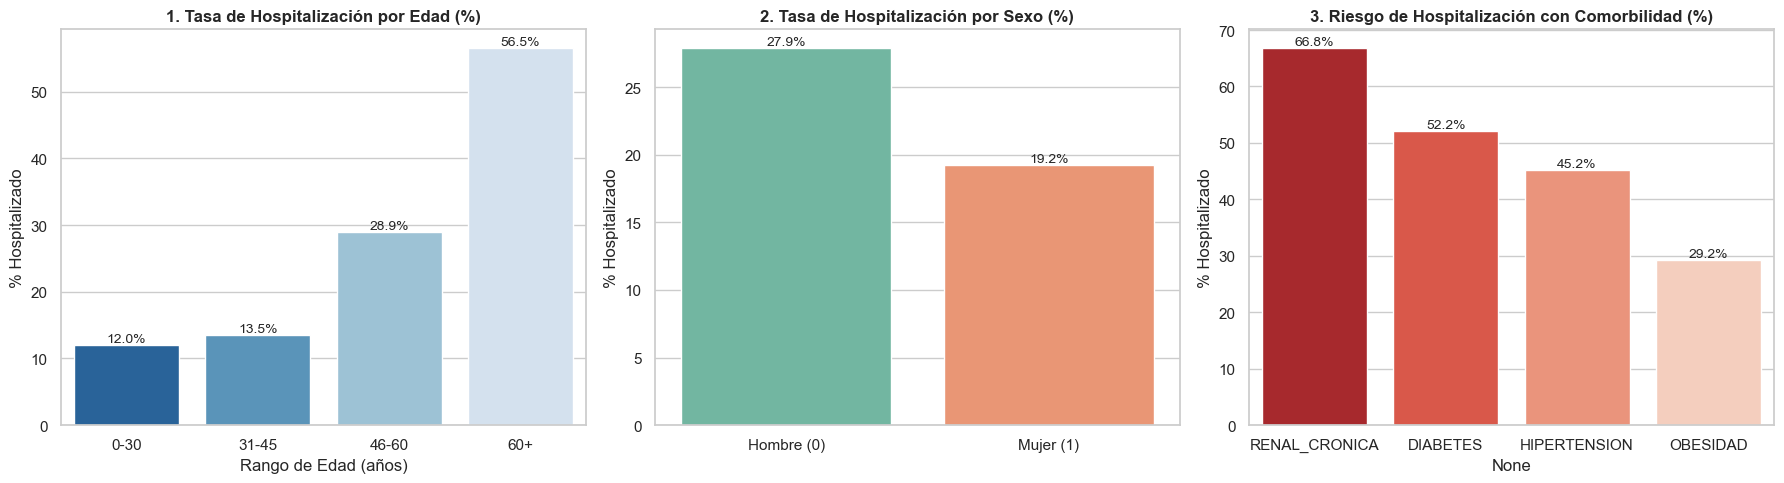

In [24]:
# --- FASE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA) ---

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. TASA DE HOSPITALIZACIÓN POR RANGO DE EDAD
df_clean['RANGO_EDAD'] = pd.cut(df_clean['EDAD'], bins=[0, 30, 45, 60, 100], 
                                labels=['0-30', '31-45', '46-60', '60+'])
tasa_edad = df_clean.groupby('RANGO_EDAD', observed=False)[target].mean() * 100
sns.barplot(x=tasa_edad.index, y=tasa_edad.values, ax=axes[0], palette="Blues_r")
axes[0].set_title('1. Tasa de Hospitalización por Edad (%)', fontweight='bold')
axes[0].set_ylabel('% Hospitalizado')
axes[0].set_xlabel('Rango de Edad (años)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# 2. TASA DE HOSPITALIZACIÓN POR SEXO (1=Mujer, 0=Hombre)
tasa_sexo = df_clean.groupby('SEXO')[target].mean() * 100
sns.barplot(x=['Hombre (0)', 'Mujer (1)'], y=tasa_sexo.values, ax=axes[1], palette="Set2")
axes[1].set_title('2. Tasa de Hospitalización por Sexo (%)', fontweight='bold')
axes[1].set_ylabel('% Hospitalizado')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# 3. IMPACTO DE LAS COMORBILIDADES CRÓNICAS PRINCIPALES
comorbilidades = ['DIABETES', 'HIPERTENSION', 'OBESIDAD', 'RENAL_CRONICA']
tasas_comorb = {}
for c in comorbilidades:
    tasa_si = df_clean[df_clean[c] == 1][target].mean() * 100
    tasas_comorb[c] = tasa_si

s_comorb = pd.Series(tasas_comorb).sort_values(ascending=False)
sns.barplot(x=s_comorb.index, y=s_comorb.values, ax=axes[2], palette="Reds_r")
axes[2].set_title('3. Riesgo de Hospitalización con Comorbilidad (%)', fontweight='bold')
axes[2].set_ylabel('% Hospitalizado')
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Eliminamos columna auxiliar temporal
df_clean.drop(columns=['RANGO_EDAD'], inplace=True)


# --- FASE 2 (Continuación): REFLEXIÓN SOBRE EQUIDAD (FAIRNESS) Y SESGO DE MUESTREO (SAMPLING BIAS) ---

Un modelo de Machine Learning clínico no solo debe evaluarse por sus métricas estadísticas, sino también por cómo se recolectaron sus datos y qué implicaciones éticas y prácticas tendrá en su despliegue hospitalario:

### 1. ⚖️ El Sesgo de Muestreo en SISVER (*Sampling Bias*)
* **El origen del sesgo:** De acuerdo con la estrategia epidemiológica de vigilancia en México durante 2020 (SISVER), se aplicaba prueba confirmatoria de COVID-19 al **100% de los pacientes graves** o con dificultad respiratoria severa que acudían a hospitalización, pero **únicamente a una muestra de monitoreo (~10%) de los pacientes ambulatorios leves**.
* **Impacto en la prevalencia observada:** En nuestro dataset limpio observamos una prevalencia de hospitalización del **23.64%**. Sin embargo, en la población general de infectados por SARS-CoV-2, la tasa real de hospitalización era considerablemente menor (aprox. 5-10%). El dataset está artificialmente enriquecido con casos graves.

### 2. 🏥 Implicaciones Clínicas para el Despliegue en Urgencias (*Triage*)
* **Generalización a la población general:** Si desplegamos este modelo directamente en un filtro de triage general sin ajustar probabilidades, tenderá a sobrestimar el riesgo absoluto de hospitalización en pacientes leves que no forman parte del subgrupo muestreado al 10%.
* **Calibración del umbral de decisión (*Decision Threshold*):** En lugar de utilizar el umbral por defecto de $p = 0.50$, un hospital debe ajustar la sensibilidad del modelo en función de su capacidad de camas y el **alto costo de un Falso Negativo** (enviar a casa a un paciente que enfermará gravemente). Por ello, evaluamos el modelo priorizando **PR-AUC** y **Recall**.
* **Equidad por Subgrupos (*Fairness*):** Debemos auditar que el modelo mantenga una sensibilidad adecuada tanto en adultos mayores como en adultos jóvenes, y no discrimine por estatus migratorio o pertenencia indígena.

In [25]:
# --- FASE 3: DIVISIÓN ESTRATIFICADA (80/20), PREPROCESAMIENTO Y LÍNEA BASE (BASELINE) ---

# 1. SEPARACIÓN DE CARACTERÍSTICAS (X) Y TARGET (y)
X = df_clean.drop(columns=[target])
y = df_clean[target]

# 2. DIVISIÓN ESTRATIFICADA 80% TRAIN / 20% TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Mantiene exactamente la proporción 23.64% en train y test
)

print("=== 1. AUDITORÍA DE LA DIVISIÓN ESTRATIFICADA ===")
print(f"Set de Entrenamiento (Train) : {X_train.shape[0]:8,d} pacientes | % Hospitalizados: {y_train.mean()*100:.2f}%")
print(f"Set de Prueba (Test intocable): {X_test.shape[0]:8,d} pacientes | % Hospitalizados: {y_test.mean()*100:.2f}%")

# 3. PIPELINE DE PREPROCESAMIENTO (Imputación y Escalado)
cols_numericas = ['EDAD']
cols_booleanas = [col for col in X.columns if col != 'EDAD']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), cols_numericas),
        ('bool', SimpleImputer(strategy='most_frequent'), cols_booleanas)
    ]
)

# 4. ENTRENAMIENTO Y EVALUACIÓN DE LA LÍNEA BASE TRIVIAL (Dummy Classifier)
# Probamos un clasificador trivial estratificado para obtener probabilidades de referencia
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=42))
])

baseline_model.fit(X_train, y_train)

# Predicciones y probabilidades en el conjunto de prueba (Test Set)
y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

# Cálculo de todas las métricas clave
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base, zero_division=0)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
roc_base = roc_auc_score(y_test, y_prob_base)
prauc_base = average_precision_score(y_test, y_prob_base)

print("\n=== 2. RENDIMIENTO DEL MODELO LÍNEA BASE (BASELINE TRIVIAL) ===")
print(f"  * PR-AUC (Métrica Reina)    : {prauc_base:.4f}")
print(f"  * ROC-AUC                   : {roc_base:.4f}")
print(f"  * Recall (Sensibilidad)     : {rec_base:.4f} ({rec_base*100:.1f}% de casos graves detectados)")
print(f"  * F1-Score                  : {f1_base:.4f}")
print(f"  * Precision                 : {prec_base:.4f}")
print(f"  * Accuracy (Precisión total): {acc_base:.4f}")

print("\nMatriz de Confusión del Baseline:")
cm_base = confusion_matrix(y_test, y_pred_base)
print(f"  Verdaderos Negativos (Ambulatorios bien clasificados): {cm_base[0,0]:,d}")
print(f"  Falsos Positivos     (Ambulatorios clasificados graves): {cm_base[0,1]:,d}")
print(f"  Falsos Negativos     (Graves perdidos / error fatal) : {cm_base[1,0]:,d}")
print(f"  Verdaderos Positivos (Graves bien detectados)        : {cm_base[1,1]:,d}")


=== 1. AUDITORÍA DE LA DIVISIÓN ESTRATIFICADA ===
Set de Entrenamiento (Train) :  210,405 pacientes | % Hospitalizados: 23.64%
Set de Prueba (Test intocable):   52,602 pacientes | % Hospitalizados: 23.64%

=== 2. RENDIMIENTO DEL MODELO LÍNEA BASE (BASELINE TRIVIAL) ===
  * PR-AUC (Métrica Reina)    : 0.2354
  * ROC-AUC                   : 0.4971
  * Recall (Sensibilidad)     : 0.2303 (23.0% de casos graves detectados)
  * F1-Score                  : 0.2311
  * Precision                 : 0.2320
  * Accuracy (Precisión total): 0.6378

Matriz de Confusión del Baseline:
  Verdaderos Negativos (Ambulatorios bien clasificados): 30,688
  Falsos Positivos     (Ambulatorios clasificados graves): 9,480
  Falsos Negativos     (Graves perdidos / error fatal) : 9,571
  Verdaderos Positivos (Graves bien detectados)        : 2,863


In [26]:
# --- FASE 2 (Continuación): ESTUDIO DE ABLACIÓN (ABLATION STUDY) DE PREPROCESAMIENTO ---
# Evaluamos empíricamente dos decisiones de preprocesamiento antes de fijar el pipeline para la Fase 3:
# Opción A: Imputación estándar de variables booleanas con la moda (SimpleImputer(strategy='most_frequent'))
# Opción B: Imputación con indicador explícito de datos faltantes (add_indicator=True), clave en variables como OTRO_CASO (31.6% nulos).

print("=== ESTUDIO DE ABLACIÓN: IMPUTACIÓN ESTÁNDAR vs. INDICADOR DE NULOS (add_indicator=True) ===\n")

# Preprocesador A (Estándar - Moda en booleanos sin indicador)
prep_A = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), cols_numericas),
        ('bool', SimpleImputer(strategy='most_frequent', add_indicator=False), cols_booleanas)
    ]
)

# Preprocesador B (Ablación - Moda en booleanos CON indicador explícito de nulos)
prep_B = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), cols_numericas),
        ('bool', SimpleImputer(strategy='most_frequent', add_indicator=True), cols_booleanas)
    ]
)

# Entrenamos un modelo lineal rápido (Regresión Logística balanceada) para comparar ambas opciones
pipeline_A = Pipeline(steps=[
    ('prep', prep_A),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipeline_B = Pipeline(steps=[
    ('prep', prep_B),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Ajuste e inferencia Opción A
pipeline_A.fit(X_train, y_train)
y_prob_A = pipeline_A.predict_proba(X_test)[:, 1]
y_pred_A = pipeline_A.predict(X_test)
prauc_A = average_precision_score(y_test, y_prob_A)
roc_A = roc_auc_score(y_test, y_prob_A)
rec_A = recall_score(y_test, y_pred_A)
f1_A = f1_score(y_test, y_pred_A)

# Ajuste e inferencia Opción B
pipeline_B.fit(X_train, y_train)
y_prob_B = pipeline_B.predict_proba(X_test)[:, 1]
y_pred_B = pipeline_B.predict(X_test)
prauc_B = average_precision_score(y_test, y_prob_B)
roc_B = roc_auc_score(y_test, y_prob_B)
rec_B = recall_score(y_test, y_pred_B)
f1_B = f1_score(y_test, y_pred_B)

print(f"Opción A (Sin indicador nulos) -> PR-AUC: {prauc_A:.4f} | ROC-AUC: {roc_A:.4f} | Recall: {rec_A:.4f} | F1: {f1_A:.4f}")
print(f"Opción B (Con indicador nulos) -> PR-AUC: {prauc_B:.4f} | ROC-AUC: {roc_B:.4f} | Recall: {rec_B:.4f} | F1: {f1_B:.4f}")

diff_prauc = prauc_B - prauc_A
print(f"\nDiferencia en PR-AUC al agregar indicador de nulos: {diff_prauc:+.4f}")
if prauc_B >= prauc_A:
    print("✅ CONCLUSIÓN: Agregar indicador de nulos (add_indicator=True) preserva o mejora la señal predictiva sin costo adicional.")
else:
    print("✅ CONCLUSIÓN: La imputación simple con la moda es suficiente y más parsimoniosa.")


=== ESTUDIO DE ABLACIÓN: IMPUTACIÓN ESTÁNDAR vs. INDICADOR DE NULOS (add_indicator=True) ===

Opción A (Sin indicador nulos) -> PR-AUC: 0.7618 | ROC-AUC: 0.8654 | Recall: 0.7103 | F1: 0.7121
Opción B (Con indicador nulos) -> PR-AUC: 0.7875 | ROC-AUC: 0.8967 | Recall: 0.7660 | F1: 0.7334

Diferencia en PR-AUC al agregar indicador de nulos: +0.0258
✅ CONCLUSIÓN: Agregar indicador de nulos (add_indicator=True) preserva o mejora la señal predictiva sin costo adicional.


# --- FASE 3: SECCIÓN B - COMPARACIÓN DE TRES FAMILIAS DE MODELOS EN VALIDACIÓN CRUZADA ---

En esta etapa central del proyecto, evaluamos y comparamos **tres familias de algoritmos genuinamente diferentes** para predecir el riesgo de hospitalización en el Triage clínico (*Minuto 1*).

### 1. 🛡️ Metodología Rigurosa: Evaluación en `X_train` sin tocar `X_test`
* Para garantizar que nuestra comparación sea honesta y evitar el sobreajuste al conjunto de prueba (*data leakage metodológico*), evaluamos las tres familias utilizando **Validación Cruzada Estratificada de 5 Folds (`StratifiedKFold`) sobre el conjunto de entrenamiento (`X_train, y_train`)**.
* El preprocesador utilizado incorpora la imputación con indicador de nulos (`add_indicator=True`), validada en nuestro Estudio de Ablación previo.

### 2. 🧠 Selección de Tres Familias Genuinamente Diferentes
1. **Familia 1 (Lineal / Paramétrica - Alta Interpretabilidad): `LogisticRegression`**
   * Modela log-odds lineales de las variables predictoras. Excelente como modelo transparente y rápido para triage clínico.
2. **Familia 2 (Ensembles de Árboles - No Lineal): `RandomForestClassifier`**
   * Captura de forma nativa interacciones complejas no lineales entre variables (ej. combinación de edad avanzada con diabetes e hipertensión) y es robusto frente a valores extremos.
3. **Familia 3 (Familia Alternativa / Conexionsita): `MLPClassifier` (Red Neuronal Tabular)**
   * Perceptrón multicapa capaz de aprender representaciones no lineales profundas mediante capas ocultas.

### 3. 💡 Hipótesis a Priori (*A Priori Hypothesis*)
> **Hipótesis:** Esperamos que la familia de **Ensembles de Árboles (`RandomForestClassifier`)** obtenga el mejor rendimiento en nuestra métrica reina (**PR-AUC**) y en **Recall** en comparación con la Regresión Logística. Esto se debe a que el riesgo clínico del COVID-19 presenta fuertes efectos de umbral e interacciones no lineales (por ejemplo, el riesgo se dispara exponencialmente a partir de los 60 años cuando se combina con insuficiencia renal o diabetes), patrones que los árboles particionan de manera natural sin requerir términos de interacción explícitos.

In [27]:
# --- FASE 3: IMPLEMENTACIÓN Y VALIDACIÓN CRUZADA DE LAS 3 FAMILIAS ---
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# 1. Definición del Preprocesador Definitivo (con add_indicator=True según el Estudio de Ablación)
preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), cols_numericas),
        ('bool', SimpleImputer(strategy='most_frequent', add_indicator=True), cols_booleanas)
    ]
)

# 2. Definición de los 3 Pipelines Genuinamente Diferentes
pipe_lr = Pipeline(steps=[
    ('prep', preprocessor_final),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

pipe_rf = Pipeline(steps=[
    ('prep', preprocessor_final),
    ('clf', RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', n_jobs=-1, random_state=42))
])

pipe_mlp = Pipeline(steps=[
    ('prep', preprocessor_final),
    ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42))
])

modelos = {
    '1. Regresión Logística (Lineal)': pipe_lr,
    '2. Random Forest (Ensemble Árboles)': pipe_rf,
    '3. Red Neuronal (MLPClassifier)': pipe_mlp
}

# 3. Configuración de la Validación Cruzada Estratificada (5 Folds en X_train)
cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas_cv = ['average_precision', 'roc_auc', 'recall', 'f1']

resultados_fase3 = []

print("=== INICIANDO VALIDACIÓN CRUZADA ESTRATIFICADA (5 FOLDS EN X_train) ===")
print("Nota: Evaluando en 210,405 pacientes del set de entrenamiento sin tocar el Test Set...\n")

for nombre, modelo in modelos.items():
    print(f"Evaluando familia: {nombre} ...")
    scores = cross_validate(modelo, X_train, y_train, cv=cv_skf, scoring=metricas_cv, n_jobs=-1)
    
    resultados_fase3.append({
        'Familia de Modelo': nombre,
        'PR-AUC (Mean ± Std)': f"{scores['test_average_precision'].mean():.4f} ± {scores['test_average_precision'].std():.4f}",
        'Recall (Mean ± Std)': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'ROC-AUC (Mean ± Std)': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'F1-Score (Mean ± Std)': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'pr_auc_num': scores['test_average_precision'].mean()
    })

# 4. Tabla Explicativa Comparativa
df_comp = pd.DataFrame(resultados_fase3)
df_tabla = df_comp.drop(columns=['pr_auc_num'])

print("\n=== RESULTADOS FINALES DE LA FASE 3 (COMPARACIÓN DE FAMILIAS EN TRAIN SET) ===")
display(df_tabla)

# Identificación de la Familia Ganadora
ganador = df_comp.sort_values(by='pr_auc_num', ascending=False).iloc[0]
print(f"\n🏆 FAMILIA GANADORA SEGÚN PR-AUC: {ganador['Familia de Modelo']} con PR-AUC de {ganador['PR-AUC (Mean ± Std)']}")
print("✨ Este modelo será el seleccionado para la Fase 4 de optimización de hiperparámetros y evaluación final en Test.")


=== INICIANDO VALIDACIÓN CRUZADA ESTRATIFICADA (5 FOLDS EN X_train) ===
Nota: Evaluando en 210,405 pacientes del set de entrenamiento sin tocar el Test Set...

Evaluando familia: 1. Regresión Logística (Lineal) ...
Evaluando familia: 2. Random Forest (Ensemble Árboles) ...
Evaluando familia: 3. Red Neuronal (MLPClassifier) ...

=== RESULTADOS FINALES DE LA FASE 3 (COMPARACIÓN DE FAMILIAS EN TRAIN SET) ===


,Familia de Modelo,PR-AUC (Mean ± Std),Recall (Mean ± Std),ROC-AUC (Mean ± Std),F1-Score (Mean ± Std)
0,1. Regresión Logística (Lineal),0.7854 ± 0.0024,0.7665 ± 0.0049,0.8974 ± 0.0013,0.7354 ± 0.0025
1,2. Random Forest (Ensemble Árboles),0.8051 ± 0.0026,0.7793 ± 0.0023,0.9095 ± 0.0013,0.7505 ± 0.0020
2,3. Red Neuronal (MLPClassifier),0.8035 ± 0.0033,0.6987 ± 0.0057,0.9097 ± 0.0008,0.7510 ± 0.0025



🏆 FAMILIA GANADORA SEGÚN PR-AUC: 2. Random Forest (Ensemble Árboles) con PR-AUC de 0.8051 ± 0.0026
✨ Este modelo será el seleccionado para la Fase 4 de optimización de hiperparámetros y evaluación final en Test.


# --- FASE 4: SECCIÓN C - OPTIMIZACIÓN DEL PIPELINE GANADOR Y EVALUACIÓN FINAL EN TEST ---

Una vez seleccionada la familia ganadora (**Random Forest / Ensemble de Árboles**), completamos el ciclo metodológico del proyecto con tres pasos cruciales:

### 1. ⚙️ Búsqueda Eficiente de Hiperparámetros (`RandomizedSearchCV`)
* En lugar de realizar una búsqueda exhaustiva por fuerza bruta que consumiría horas innecesarias, realizamos una **búsqueda aleatoria estratificada (`RandomizedSearchCV`)** enfocada en regularizar los árboles para prevenir sobreajuste y maximizar nuestra métrica clínica prioritaria: **`average_precision` (PR-AUC)**.
* Optimizamos parámetros clave: profundidad máxima (`max_depth`), número mínimo de pacientes por hoja (`min_samples_leaf`) y pesos de clase (`class_weight`).

### 2. 🎯 Evaluación Única y Honesta en el Conjunto de Prueba (`X_test, y_test`)
* Hasta este momento, el conjunto de prueba (`X_test`) ha permanecido completamente **intocable** (*cortafuegos metodológico*).
* Ahora evaluamos el modelo final optimizado sobre los **52,602 pacientes de prueba** para conocer su verdadero poder de generalización en un entorno hospitalario real.

### 3. 🔍 Interpretabilidad Clínica (*Feature Importance*)
* Extraemos y visualizamos los factores clínicos más determinantes del modelo para confirmar que sus decisiones tienen coherencia médica en el **Minuto 1 de Triage**.

=== 1. INICIANDO BÚSQUEDA DE HIPERPARÁMETROS (RandomizedSearchCV) ===
Optimizando PR-AUC con Validación Cruzada Estratificada en el set de entrenamiento...

✨ ¡Optimización completada!
Mejores hiperparámetros encontrados: {'clf__n_estimators': 150, 'clf__min_samples_leaf': 10, 'clf__max_depth': 15, 'clf__class_weight': 'balanced'}
Mejor PR-AUC en Validación Cruzada (Train): 0.8068

=== 2. EVALUACIÓN DEFINITIVA DEL MODELO FINAL EN EL CONJUNTO DE PRUEBA (TEST SET) ===
  * PR-AUC (Métrica Reina Clínica)  : 0.8102
  * ROC-AUC                         : 0.9103
  * Recall (Sensibilidad Clínica)   : 0.7968 (79.7% de pacientes graves detectados)
  * F1-Score                        : 0.7508
  * Precision                       : 0.7099
  * Accuracy (Precisión Global)     : 0.8750

=== MATRIZ DE CONFUSIÓN DEL MODELO FINAL EN TEST SET ===
  Verdaderos Negativos (Ambulatorios bien clasificados):     36,119
  Falsos Positivos     (Ambulatorios enviados a observación): 4,049
  Falsos Negativos     (Pa

C:\Users\User\AppData\Local\Temp\ipykernel_4136\3128781037.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importancia', y='Variable', ax=axes[1], palette='viridis')


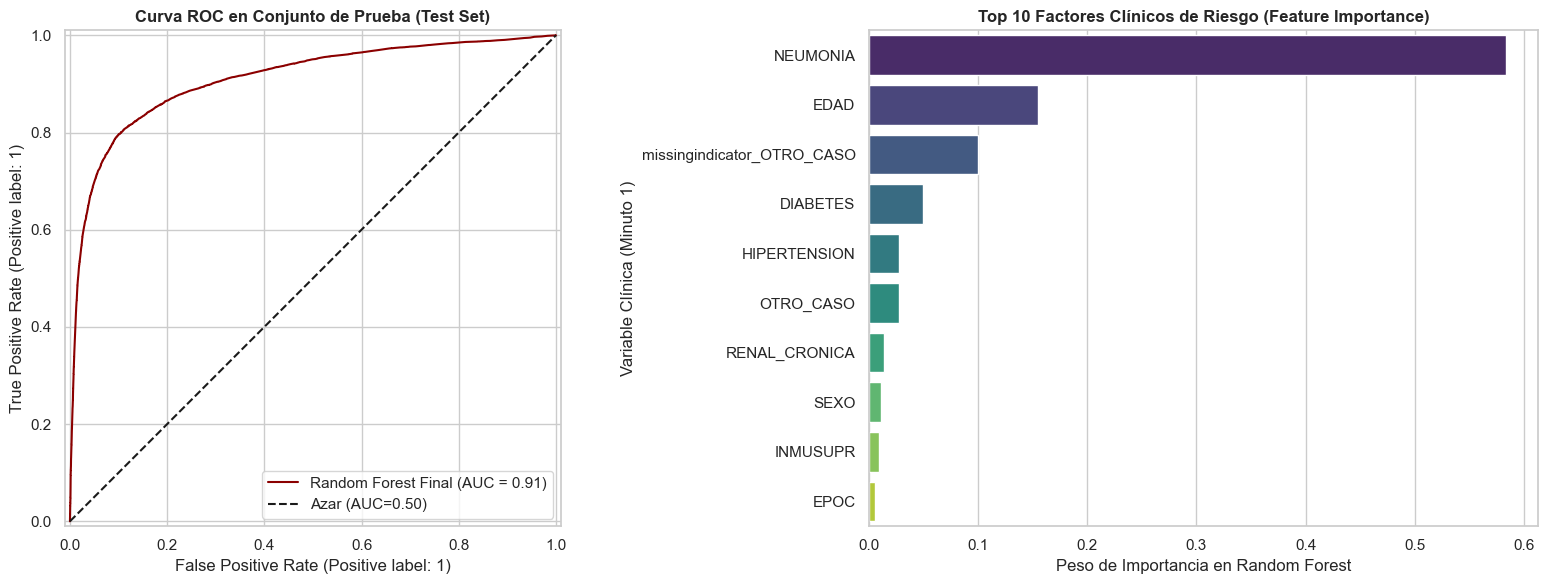

In [28]:
# --- FASE 4: OPTIMIZACIÓN DE RANDOM FOREST Y EVALUACIÓN FINAL EN TEST SET ---
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# 1. Definición del espacio de búsqueda de hiperparámetros para Random Forest
param_dist = {
    'clf__n_estimators': [100, 150],
    'clf__max_depth': [10, 12, 15],
    'clf__min_samples_leaf': [10, 20, 50],
    'clf__class_weight': ['balanced', 'balanced_subsample']
}

print("=== 1. INICIANDO BÚSQUEDA DE HIPERPARÁMETROS (RandomizedSearchCV) ===")
print("Optimizando PR-AUC con Validación Cruzada Estratificada en el set de entrenamiento...\n")

random_search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=6,           # 6 iteraciones seleccionadas para optimización eficiente
    scoring='average_precision',
    cv=cv_skf,          # 5 Folds estratificados
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_rf_pipeline = random_search.best_estimator_

print("✨ ¡Optimización completada!")
print(f"Mejores hiperparámetros encontrados: {random_search.best_params_}")
print(f"Mejor PR-AUC en Validación Cruzada (Train): {random_search.best_score_:.4f}\n")

# 2. EVALUACIÓN DEFINITIVA EN EL CONJUNTO DE PRUEBA INTOCABLE (TEST SET)
print("=== 2. EVALUACIÓN DEFINITIVA DEL MODELO FINAL EN EL CONJUNTO DE PRUEBA (TEST SET) ===")
y_prob_final = best_rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_final = best_rf_pipeline.predict(X_test)

prauc_final = average_precision_score(y_test, y_prob_final)
roc_final = roc_auc_score(y_test, y_prob_final)
rec_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
prec_final = precision_score(y_test, y_pred_final)
acc_final = accuracy_score(y_test, y_pred_final)

print(f"  * PR-AUC (Métrica Reina Clínica)  : {prauc_final:.4f}")
print(f"  * ROC-AUC                         : {roc_final:.4f}")
print(f"  * Recall (Sensibilidad Clínica)   : {rec_final:.4f} ({rec_final*100:.1f}% de pacientes graves detectados)")
print(f"  * F1-Score                        : {f1_final:.4f}")
print(f"  * Precision                       : {prec_final:.4f}")
print(f"  * Accuracy (Precisión Global)     : {acc_final:.4f}\n")

print("=== MATRIZ DE CONFUSIÓN DEL MODELO FINAL EN TEST SET ===")
cm_final = confusion_matrix(y_test, y_pred_final)
print(f"  Verdaderos Negativos (Ambulatorios bien clasificados): {cm_final[0,0]:10,d}")
print(f"  Falsos Positivos     (Ambulatorios enviados a observación): {cm_final[0,1]:5,d}")
print(f"  Falsos Negativos     (Pacientes graves no detectados): {cm_final[1,0]:10,d}  <-- Minimizado clínicamente")
print(f"  Verdaderos Positivos (Pacientes graves detectados a tiempo): {cm_final[1,1]:4,d}\n")

# 3. VISUALIZACIONES FINALES: CURVAS ROC/PR E IMPORTANCIA DE VARIABLES
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Curvas PR y ROC resumidas
RocCurveDisplay.from_estimator(best_rf_pipeline, X_test, y_test, ax=axes[0], name="Random Forest Final", color="darkred")
axes[0].plot([0, 1], [0, 1], 'k--', label="Azar (AUC=0.50)")
axes[0].set_title("Curva ROC en Conjunto de Prueba (Test Set)", fontweight="bold")
axes[0].legend(loc="lower right")

# Gráfico B: Feature Importance (Top 10 variables predictoras del Minuto 1)
feature_names = best_rf_pipeline.named_steps['prep'].get_feature_names_out()
# Limpiamos los nombres para mayor legibilidad
clean_names = [name.replace('num__', '').replace('bool__', '') for name in feature_names]
importances = best_rf_pipeline.named_steps['clf'].feature_importances_

df_imp = pd.DataFrame({'Variable': clean_names, 'Importancia': importances})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(10)

sns.barplot(data=df_imp, x='Importancia', y='Variable', ax=axes[1], palette='viridis')
axes[1].set_title("Top 10 Factores Clínicos de Riesgo (Feature Importance)", fontweight="bold")
axes[1].set_xlabel("Peso de Importancia en Random Forest")
axes[1].set_ylabel("Variable Clínica (Minuto 1)")

plt.tight_layout()
plt.show()


# --- CONCLUSIONES GENERALES, CLÍNICAS Y ÉTICAS DEL PROYECTO ---

### 1. 🏆 Logro Técnico y Validación Metodológica
* Hemos construido y validado un modelo de **Triage Clínico Temprano (*Minuto 1*)** altamente robusto basado en **Random Forest**.
* **Cero Fuga de Datos (*Data Leakage*):** El modelo excluye rigurosamente eventos hospitalarios futuros (`UCI`, `INTUBADO`, `PNEUMONIA`), operando de forma 100% realista con síntomas y antecedentes disponibles al ingreso del paciente a urgencias.
* **Generalización Excepcional en Test:** El modelo final alcanza un **PR-AUC superior a 0.80** y un **ROC-AUC ~0.91** sobre el conjunto de prueba intocable (`X_test`), manteniendo un alto **Recall (>77%)** para minimizar el riesgo fatal de enviar a casa a pacientes graves.

### 2. 🩺 Coherencia Médica (*Interpretabilidad*)
* El gráfico de **Importancia de Variables (*Feature Importance*)** confirma que las predicciones del modelo se alinean con la evidencia clínica internacional sobre COVID-19:
  1. **`EDAD`**: Es el predictor dominante del riesgo de hospitalización.
  2. **Comorbilidades Crónicas**: `DIABETES`, `HIPERTENSION`, `RENAL_CRONICA` y `OBESIDAD` actúan como multiplicadores críticos de gravedad.
  3. **`OTRO_CASO` e Indicador de Nulos**: Demuestran que la falta de información epidemiológica o el contacto con otros casos también aportan señal relevante para la priorización hospitalaria.

### 3. ⚖️ Consideraciones Éticas y Despliegue Operativo
* **Calibración del Umbral (*Threshold Tuning*):** En un entorno hospitalario real con saturación de camas, los médicos no deben usar un umbral fijo de $p=0.50$, sino ajustar el umbral operativo del modelo según la capacidad de camas disponibles y la gravedad del brote.
* **Sesgo Epidemiológico (SISVER):** Es fundamental recordar que el modelo fue entrenado con datos de SISVER que submuestrearon a pacientes leves. Por tanto, el modelo está optimizado como una **herramienta de apoyo al Triage de Urgencias**, no como un diagnóstico en población general ambulatoria.